## Analisis de la cultura culinaria en La Habana y sus locales.

La Habana, capital de Cuba, es una deslumbrante ciudad enclavada en la antiguamente llamada Bahía de Carenas. Con una posición geográfica especial y un acervo cultural único, desarrolla un papel que interesa a personas dentro y fuera de la isla a pesar, de no ser igualmente valorada y respetada por otros.
El acervo cultural del cual hablamos anteriormente viene también del arte culinario mixto que abarca. Enfocándose en ello, llegaremos a conclusiones valiosas acerca del tema con un análisis sobre el desarrollo de los locales como restaurantes, bares y cafeterías de nivel en la ciudad.

Para ello se tomara 10 locales de todos los municipios y 30 especificamente de Habana Vieja, Habana del Este y Diez de Octubre. Estos 3 ultimos dado que Habana Vieja es el campo historico de la ciudad, Habana del Este ya que tiene las mejores playas de la capital con gran atractivo de verano, ademas, es un municipio relativamente importante y, Diez de Octubre para valorar en suficiencia los estadisticos de algun municipio que quede fuera del vistoso panorama habanero usual. Todo esto para un total de 202 locales registrados en la base.  

Luego de tener su base de datos ya establecida, creamos un programa que itera y accede a cada fichero para extraer los datos que buscamos procesar juntandolos en un dataframe:

In [1]:
import os
import json
import pandas as pd
import MyLibrary as ml
import matplotlib.pyplot as plt
import statistics as st

# Extraer los datos y conversion a dataframe:

route = "C:\\JSON Data\\All In One"

info_list = ml.data_extraction_il(route)
database = ml.data_extraction_df(route)
database_n = pd.json_normalize(info_list)

print(database)

                Place                                           Location  \
0          700 Grados  {'Address': 'Avenida 41, esquina 86', 'Municip...   
1        Abuelo D'Oro  {'Address': 'Calzada Aldabo entre 12 y 13, Ald...   
2    Aires de Cojimar  {'Address': 'Pezuela #3e05 entre RUA y Esparte...   
3        Al Campestre  {'Address': 'El Intermitente, Via  Blanca, Ala...   
4             Allegro  {'Address': 'Paseo de la Villa, Villa Panameri...   
..                ...                                                ...   
197   Villa Hernandez  {'Address': '#112, Calle San Miguel entre Gela...   
198          Vistamar  {'Address': '#2206, Avenida 1ra entre 22 y 24,...   
199            Yarini  {'Address': '#214, Calle San Isidro entre Pico...   
200  Yesterday Habana  {'Address': 'Calle Rita entre Calzada de Guine...   
201          Yucasabi  {'Address': '#60, Calle Obrapia entre Avenida ...   

               Classification   Specialization Ownership  \
0                   Cafeter

Despues de extraer los datos y almacenarlos en variable podemos con un nivel medianamente básico de algoritmia, estadística elemental y visualización de datos entender como proceder. 

#### Para empezar, se determinara como estructurar los analisis de la forma mas eficiente, llegando a las etapas siguientes para cada tema de estudio que las requiera:

1- Analisis exploratorio de datos o EDA, que permite una visualizacion inicial de su dataset, observar tendencias o anomalias, verificar posibles correlaciones entre las variables con las cuales se trabaja y hacer limpieza de datos.

2- Procesamiento de los datos y la realizacion de los respectivos analisis deseados.

3- Extraccion de conclusiones a partir de la observacion de los resultados.

Antes de ello es buena idea ver con que tipos de datos o estructuras de datos con las que se cuenta y cuales variables tienen valores nulos para predecir de antemano como manejarlos: 

In [2]:
print(database.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Place                202 non-null    object 
 1   Location             202 non-null    object 
 2   Classification       202 non-null    object 
 3   Specialization       202 non-null    object 
 4   Ownership            202 non-null    object 
 5   Schedule             202 non-null    object 
 6   Ratings              202 non-null    object 
 7   Reservations         201 non-null    object 
 8   Delivery             202 non-null    object 
 9   Phone                183 non-null    object 
 10  Accounts or website  202 non-null    object 
 11  Payment              202 non-null    object 
 12  Capacity             199 non-null    float64
 13  Parking service      202 non-null    bool   
 14  Wifi                 202 non-null    bool   
 15  Smoking area         202 non-null    boo

Aqui es percatable la presencia de valores nulos (None values) en las variables de Reservations (1 debido a que estaban habilitando el sistema de reservas en dicho restaurante intermitentemente), Phone (19 que no tienen contacto telefonico) y Capacity (3 por remodelaciones del lugar). El conocimiento y localizacion de este tipo de datos les ayudaria a evitar problemas con el codigo luego al procesar los datos. Es visible ver que tienen 17 claves principales en total de las cuales sus valores en 13 eran objetos ya sea por ser estructuras de datos o strings, otros 3 son booleanos y uno es numerico. Conociendo asi los valores del data set ya pueden empezar.

### Una visible y dolorosa deficiencia de poder adquisitivo. 

Una vez que se pusieron en equipo manos a la obra determinaron que posibles "topics" se podian estudiar y definieron campos para acotar el uso de datos a solo lo necesario aunque a veces hay que relacionar datos de diferentes dominios para topar con raices del problema. Entre estos temas estaban los contextos economicos de la poblacion, asunto que surge dadas las constantes preguntas de turistas respecto a ello en sus intentos de entender el complicado ambiente coloquial. Una pregunta normal es: Le seria posible a un cubano comun acceder a un bar o restaurante con su salario estandar?

<function matplotlib.pyplot.show(close=None, block=None)>

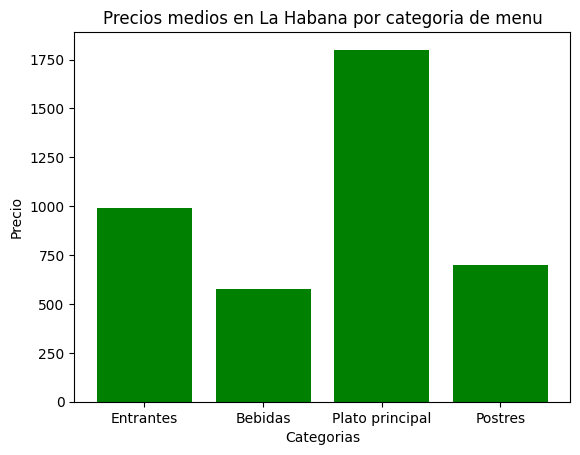

In [3]:
a,b,c,d = "Starters","Drinks","Main course","Desserts"

starters_prices = ml.cat_prices(info_list,a)
drinks_prices = ml.cat_prices(info_list,b)
main_prices = ml.cat_prices(info_list,c)
dessert_prices = ml.cat_prices(info_list,d)

starts_m = ml.median_calculus(starters_prices)
drinks_m = ml.median_calculus(drinks_prices)
main_m = ml.median_calculus(main_prices)
desserts_m = ml.median_calculus(dessert_prices)

xaxis = ["Entrantes","Bebidas","Plato principal","Postres"]
yaxis = [starts_m,drinks_m,main_m,desserts_m]

plt.bar(xaxis,yaxis,color = "green")
plt.xlabel("Categorias")
plt.ylabel("Precio")
plt.title("Precios medios en La Habana por categoria de menu")
plt.show

4068


<function matplotlib.pyplot.show(close=None, block=None)>

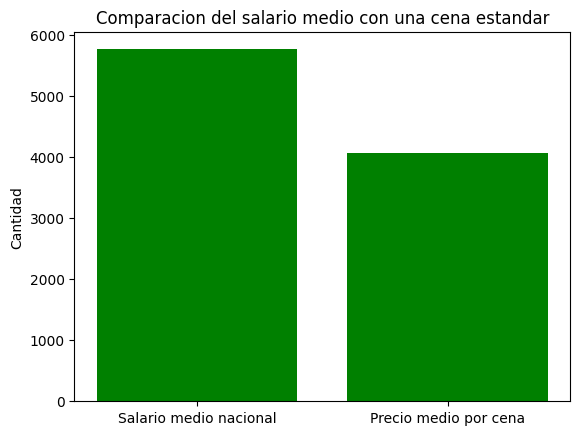

In [4]:
mean_cost_per_dinner = sum(yaxis)
mean_national_salary = 5762
xaxis1 = ["Salario medio nacional","Precio medio por cena"]
yaxis1 = [mean_national_salary,mean_cost_per_dinner]
print(round(mean_cost_per_dinner))

plt.bar(xaxis1,yaxis1,color="green")
plt.title("Comparacion del salario medio con una cena estandar")
plt.ylabel("Cantidad")
plt.show

El precio aproximado de una cena en La Habana es de 4070 pesos. Para una difencia de 1695 pesos del salario respecto al costo de una cena promedio, los cubanos claramente tenemos un serio problema en nuestras manos. No deberia ocurrir que un placer momentaneo le cueste a un trabajador humilde casi lo que lucha en un mes de trabajo. Segun lo escrito por Presidencia de Cuba en un articulo de su pagina, el salario medio de Cuba en 2024 fue de 5762 pesos.

### Una muestra de incomprension o desinteres social?

Que probabilidades tiene un vegetariano de entrar a un restaurante-cafeteria de nuestra ciudad y por suerte encontrarse con alguna variedad de platos o tan siquiera uno que satisfaga sus necesidades?. En esto se podria buscar informacion relevante para recomendar a restaurantes y bares podria hacer que tengan mas alcance comercial al incluir todas las opciones posibles en su variedad. 

Es posible contabilizar cuantos platos vegetarianos ofrece cada local registrado en la base y obtener estadisticos relativos al analisis de forma que podamos inferirlos como parametros generales de lo estudiado. 

In [5]:
dict1 = ml.veg_cuantity(route)
dict1 = pd.DataFrame(dict1.values(),dict1.keys())
print(dict1.describe())

                0
count  202.000000
mean     6.866337
std      4.437174
min      0.000000
25%      4.000000
50%      6.000000
75%      9.000000
max     30.000000


Entre esto se obtiene que, hay locales que no ofrecen ningun tipo de plato en este aspecto (dado que el minimo es 0) y el maximo que va a ofrecer algun local de los estudiados es 30 platos vegetarianos.

In [6]:
ml.median_calculus(dict1[0])

6.0

Por otra parte, el valor de la mediana nos indica que la cantidad media de opciones de este tipo que ofrecen los locales en su conjunto es de 6 platos. Ademas de esto, vale la pena preguntarse, cuales serian los 10 restaurantes que encabezan la lista en variedad de platos consumibles para una dieta vegetariana?

In [7]:
dict1[0].nlargest(10)

Mimosa.json              30
La Juliana.json          21
La Vitrola.json          18
Bone Ma 62.json          16
Los Chinos Pizza.json    16
Ole-Ole.json             16
Sapori.json              16
El Farallon.json         15
La Fela.json             15
Lacret 559.json          15
Name: 0, dtype: int64

Un tema a tocar respecto a esto es, si los restaurantes en general son lo suficientemente inclusivos en su menu con personas vegetarianas dado que, por ejemplo, una persona va con un grupo de amigos, pero cae en desventaja al no tener los negocios opciones de respaldo para estos casos. Hay casos de personas que en muchos casos han tenido que dejar de comer por no tener opciones relevantes de este tipo en un menu.

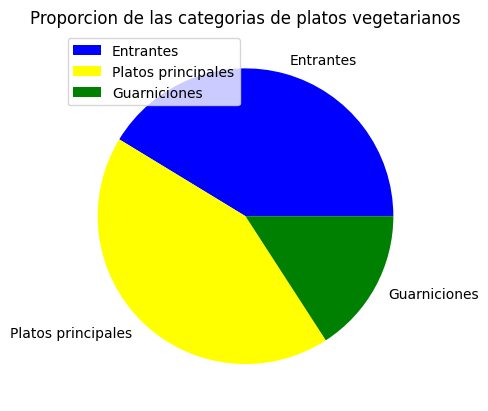

In [8]:
veg_data = ml.veg_cat_list(info_list)
veg_data.count("Starters")
veg_data.count("Main course")
veg_data.count("Siders")

new_list = ["Entrantes","Platos principales","Guarniciones"]
new_list1 = [veg_data.count("Starters"),veg_data.count("Main course"),veg_data.count("Siders")]
plt.pie(new_list1,labels = new_list, colors = ["blue","yellow","green"])
plt.title("Proporcion de las categorias de platos vegetarianos")
plt.legend(new_list)

Entre las posibles opciones para un vegetariano en La Habana ocurre que hay tecnicamente la misma cantidad de entrantes que de platos principales, lo que da a indicar en algo una tendencia a que en muchos lugares es probable que las unicas opciones que tengan los personas con este modo de vida sean platos secundarios (entrantes, guarniciones o postres claro, pero este ultimo no ha sido tenido en cuenta puesto a que en una cena no se va a ir a solamente comer un postre). Esto nos da a ver que muchos locales en la ciudad que se dedican a comida mixta pudieran aumentar su alcance comercial incluso con agencias de turismo que buscan satisfacer las necesidades de clientes que a veces son vegetarianos si amplian su menu para ser mas inclusivos, ya que es un mercado casi sin explotar en Cuba.

Como dato curioso, entre los lugares que se analizaron el unico que se puede decir "vegetariano" es El Cafe en Habana Vieja y, este en su variedad no se encuentra en nuestra anterior lista de los 10 que encabezan la lista en cantidad de platos de este tipo.

### Con vista al futuro:

Un tema interesante es cuan digitalizados estan los centros gastronomicos en La Habana:

<function matplotlib.pyplot.show(close=None, block=None)>

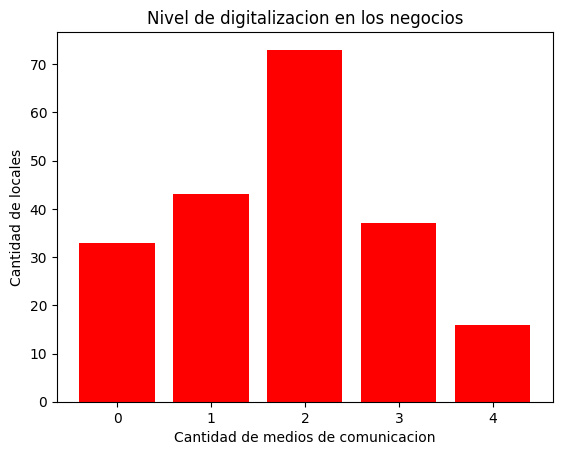

In [9]:
dig_list = ml.digitalization_info(database)

plt.bar(dig_list[0],dig_list[1],color = "red")
plt.title("Nivel de digitalizacion en los negocios")
plt.xlabel("Cantidad de medios de comunicacion")
plt.ylabel("Cantidad de locales")
plt.show

Se observa una tendencia central que nos da a estimar que la mayoria de locales mantienen una media-baja presencia en las vias de comunicacion digital. Si tomamos la mitad izquierda del grafico, esta representa un 73,76% del total de negocios. Ademas, solo 16 de 202 tienen todos los medios digitales posibles (Facebook, Instagram, Sitio web, Email) para sus clientes mientras que otros 33 no tienen absolutamente ninguno.

#### Un aspecto mas a tener en cuenta cuando se habla de nivel de informatizacion es la internet, lo cual se deberia visualizar tambien:

<function matplotlib.pyplot.show(close=None, block=None)>

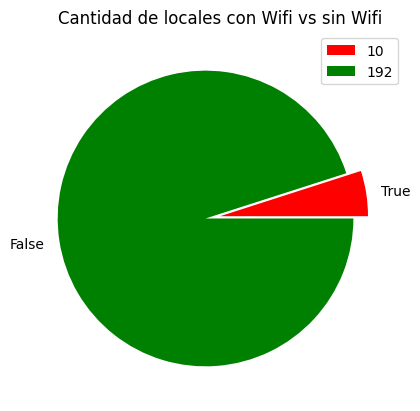

In [10]:
wifi_val = [] 
wifi_df = database["Wifi"]
for i in wifi_df:
    wifi_val.append(i)
wifi_dic = {}
wifi_dic[True] = wifi_val.count(True)
wifi_dic[False] = wifi_val.count(False)

plt.pie(wifi_dic.values(),labels = wifi_dic.keys(),colors = ["red","green"],explode = (0,0.1))
plt.title("Cantidad de locales con Wifi vs sin Wifi")
plt.legend(labels = wifi_dic.values())
plt.show

En realidad es bastante de esperar que resultara eso, el coste de mantener wifi libre no vale la pena actualmente mas que para llamar atencion. Ademas, por lo general indirectamente los negocios prefieren salir de los clientes lo mas rapido posible para asi tener mayor capacidad para otros nuevos, por ende, prefieren que el cliente realice la estancia en un tiempo limitado dado que muchos luego de terminar no consumen mas nada y se quedan conversando, etc...

Tambien se debe tener en cuenta la cantidad de locales que cuentan con numero de telefono (datos que podemos obtener de la segunda tabla que se creo), pues esta siempre es la via mas directa de comunicarse con posibles clientes:

<function matplotlib.pyplot.show(close=None, block=None)>

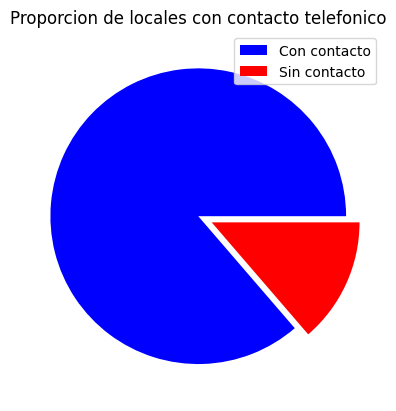

In [11]:
dict3 = {"Con contacto":183,"Sin contacto":29}

plt.pie(dict3.values(),colors = ["blue","red"],explode = (0,0.1))
plt.title("Proporcion de locales con contacto telefonico")
plt.legend(dict3.keys())
plt.show

### Una cuestion de capacidad:

Otra idea de analizar los locales es preguntarse que capacidad media brinda cada municipio, ya que es adecuado tener manera de saber que lugares permiten por sus condiciones la visita en familias numerosas (por lo general esos son los que menos convencimiento llevan para permitir a un gran grupo turistico en sus infraestructuras) y, las personas poder tener idea de a cuales consultar en caso de buscar local para realizar un festividad, etc...

Ya que en nuestra segunda tabla se veia que superficialmente la clave "Capacity" era el unico valor numerico a la vista, directamente realizar calculos es una opcion, pero no sin antes limpiar el dataframe de None values.

<function matplotlib.pyplot.show(close=None, block=None)>

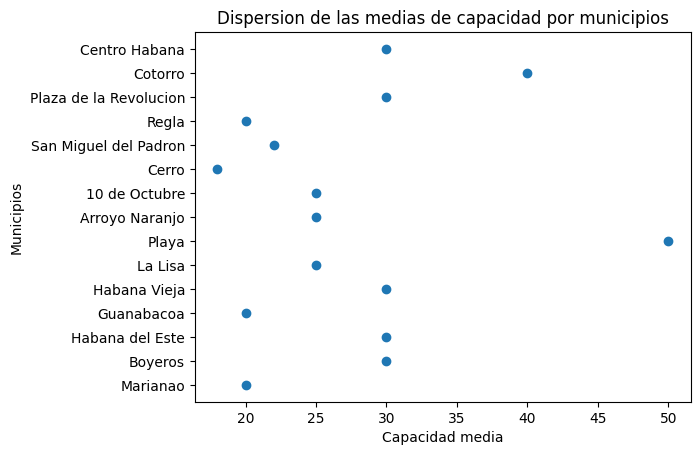

In [12]:
cap_data = ml.capacity_procesing(database_n)

plt.scatter(cap_data[1],cap_data[0])
plt.title("Dispersion de las medias de capacidad por municipios")
plt.xlabel("Capacidad media")
plt.ylabel("Municipios")
plt.show

Definitivamente Playa es el mejor municipio para comenzar a buscar un lugar adecuado para fiestas. Segun los puntos, los que menos capacidad tienen son Cerro, Marianao, Guanabacoa y Regla. Por otro lado, el unico municipio que se acerca en algo a Playa es el Cotorro, uno que no parecia que destacaria dado la poca densidad poblacional que tiene respecto a otros que se le quedaron atras como Habana Vieja. La mediana fue usada aqui ya que la media aritmetica resulta ser muy vulnerable a los valores "outliers" o sobresalientes.

Podriamos analizar si los ratings de los locales estan relacionados en alguna medida con condiciones respecto a materia de variedad de ofertas, digitalizacion y nivel de alcance comercial, lo cual explicare adelante.

### Analisis de variedad:

Cuales son los lugares que mayor cantidad de platos ofrecen dentro de su menu por categoria?, me pregunto. Esto es un indicador del nivel de expansion y especializacion gastronomica dentro del ambito de cada negocio y seria esencial para denotar cuales son los que se toman mas en serio su desarrollo culinario. Ademas, podriamos ver las distibuciones de platos "mayorando" las cantidades y haciendo un grafico de barras:

Text(0, 0.5, 'Cantidad de entrantes')

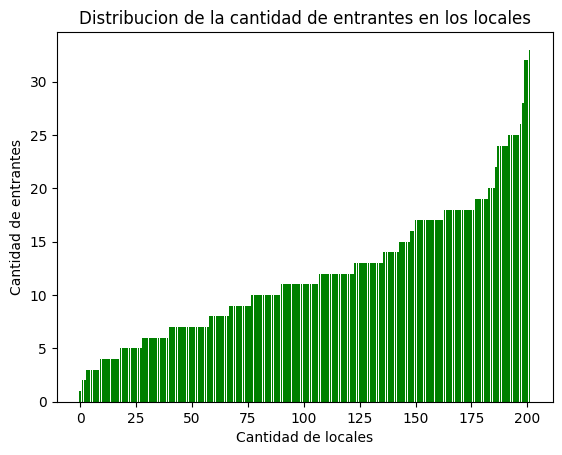

In [13]:
starters_q = ml.cat_quant(info_list,"Starters")
main_q = ml.cat_quant(info_list,"Main course")
drinks_q = ml.cat_quant(info_list,"Drinks")
desserts_q = ml.cat_quant(info_list,"Desserts")

sorted_starters_quant = dict(sorted(starters_q.items(),key = ml.obtein_value))
    
plt.bar([x for x in range(202)],sorted_starters_quant.values(),color = "green")
plt.title("Distribucion de la cantidad de entrantes en los locales")
plt.xlabel("Cantidad de locales")
plt.ylabel("Cantidad de entrantes")

Text(0, 0.5, 'Cantidad de platos')

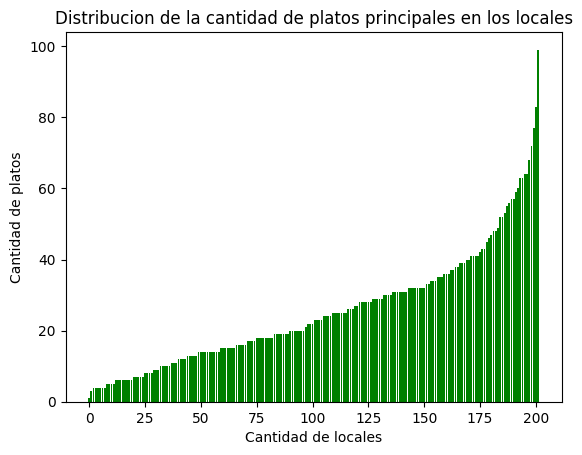

In [14]:
sorted_main_quant = dict(sorted(main_q.items(),key = ml.obtein_value))
    
plt.bar([x for x in range(202)],sorted_main_quant.values(),color = "green")
plt.title("Distribucion de la cantidad de platos principales en los locales")
plt.xlabel("Cantidad de locales")
plt.ylabel("Cantidad de platos")

Text(0, 0.5, 'Cantidad de bebidas')

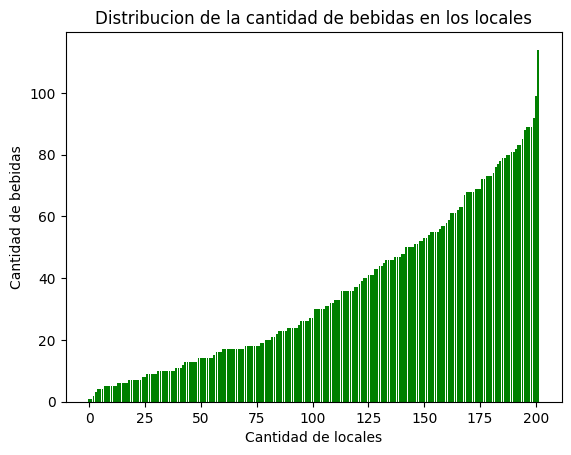

In [15]:
sorted_drink_quant = dict(sorted(drinks_q.items(),key = ml.obtein_value))
    
plt.bar([x for x in range(202)],sorted_drink_quant.values(),color = "green")
plt.title("Distribucion de la cantidad de bebidas en los locales")
plt.xlabel("Cantidad de locales")
plt.ylabel("Cantidad de bebidas")

Text(0, 0.5, 'Cantidad de postres')

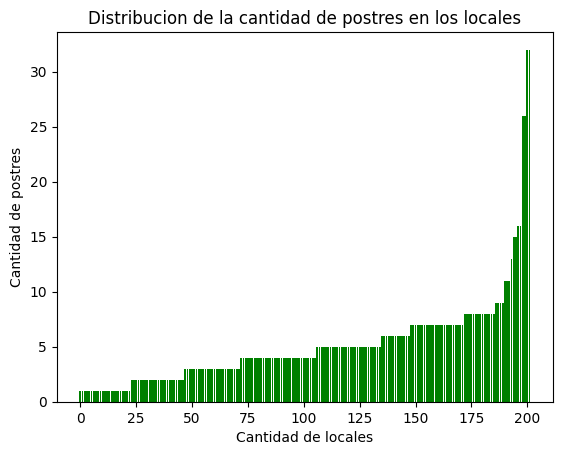

In [16]:
sorted_dessert_quant = dict(sorted(desserts_q.items(),key = ml.obtein_value))
    
plt.bar([x for x in range(202)],sorted_dessert_quant.values(),color = "green")
plt.title("Distribucion de la cantidad de postres en los locales")
plt.xlabel("Cantidad de locales")
plt.ylabel("Cantidad de postres")

De aqui se tiene que: En los entrantes 150 aproximadamente de los 202 lugares tienen menos de 15 en oferta (una cifra relativamente normal), 175 tienen menos de 40 platos principales, la mitad tiene menos de una variedad de 30 bebidas en oferta y casi todos tienen menos de 10 postres en su menu. Esto viene dando una idea de cual es la mediana para cada categoria pero ahora viendo la distribucion completa para todos los lugares como un estilo de vista panoramica al asunto.

In [17]:
starter_quant = [x for x in starters_q.values()]
main_quant = [x for x in main_q.values()]
drink_quant = [x for x in drinks_q.values()]
dessert_quant = [x for x in desserts_q.values()]

var_dict = {}
for a,b,c,d,e in zip(starter_quant,main_quant,drink_quant,dessert_quant,info_list):
    var_dict[e["Place"]] = a + b + c + d

var_df = pd.DataFrame(var_dict,index = range(1),columns = var_dict.keys())

print(var_df.iloc[0].nlargest(10))

 La Mimosa             186
Tanokura               185
D'Next                 180
Villa Hernandez        179
Parrandas Grill Bar    168
Paladar Don Omar       162
La Concordia           151
Los Compadres          149
Betty Boom             146
Ole-Ole                145
Name: 0, dtype: int64


Estos son los 10 que encabezan la lista en variedad de ofertas que se analizan, con 186 ofertas como maximo. Nos da a entender cual es el limite superior de la variedad de ofertas en La Habana para lo que se tiene de muestra.

Con esta investigacion ya elaborada tenemos ya mas de conocimiento y vision para lo que sucede en la realidad gastronomica habanera en nuestros dias.